# Data Exploration

Kamryn Mansfield

In [ ]:

library(tidyverse)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   3.5.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Linking to GEOS 3.13.0, GDAL 3.8.5, PROJ 9.5.1; sf_use_s2() is TRUE

Combine HSIS Data:

I made a function to combine the data, but they are too big for github. So I put folder they are saved to in the gitignore.

In [ ]:
#### COMBINE HSIS DATA ####
# run this once to combined the files

# The folder with the hsis data you want to combine
# hsis_folder <- "../1_data/HSIS Charlotte Data/"
#
# This functions combines the appropriate hsis files if you have multiple years
# combine_HSIS_files(hsis_folder)


In [ ]:
#### PULL IN AND CLEAN DATA ####
combined_hsis_folder <- "../1_data/HSIS Charlotte Data/combined_data/"

busstop_data <- read_csv(paste0(combined_hsis_folder, "/","combined_18_to_24_catsStops.csv"))


New names:
Rows: 20994 Columns: 12
── Column specification
──────────────────────────────────────────────────────── Delimiter: "," chr
(8): Bench, Shelter, routes, Direction, Pole_Locat, Sidewalk, Trans_P, o... dbl
(4): ...1, StopID, x, y
ℹ Use `spec()` to retrieve the full column specification for this data. ℹ
Specify the column types or set `show_col_types = FALSE` to quiet this message.
• `` -> `...1`

New names:
Rows: 265157 Columns: 22
── Column specification
──────────────────────────────────────────────────────── Delimiter: "," chr
(13): DATE_VAL, CRASH_TYPE, LIT, WTHR, PRIMARY, SECONDARY, URBAN_RU, RD_... dbl
(9): ...1, CRSH_ID, DATE_VAL_Y, MILT_TIME, CRSH_LEVL, LATITUDE, LONGITU...
ℹ Use `spec()` to retrieve the full column specification for this data. ℹ
Specify the column types or set `show_col_types = FALSE` to quiet this message.
• `` -> `...1`

Making a data frame that will give true for each column that had no changes throughout the year

In [ ]:
stop_changes <- busstop_data |>
  group_by(StopID) |>
  summarise(x_unq = length(unique(x)) == 1,
            y_unq = length(unique(y)) == 1,
            Bench_unq = length(unique(Bench)) == 1,
            Shelter_unq = length(unique(Shelter)) == 1,
            routes_unq = length(unique(routes)) == 1,
            Direction_unq = length(unique(Direction)) == 1,
            Pole_Locat_unq = length(unique(Pole_Locat)) == 1,
            Sidewalk_unq = length(unique(Sidewalk)) == 1,
            Trans_P_unq = length(unique(Trans_P)) == 1,
            orgnl_file = length(unique(orgnl_file)) == 1)


it looks like there have been some changes throughout the year

In [ ]:
colSums(stop_changes)


        StopID          x_unq          y_unq      Bench_unq    Shelter_unq 
      98245785            147            147           3136           3134 
    routes_unq  Direction_unq Pole_Locat_unq   Sidewalk_unq    Trans_P_unq 
          2770           3148           3148           3149           3150 
    orgnl_file 
            57 

looking at the unique stop ids

In [ ]:
stop_id_count <- busstop_data |>
  group_by(StopID) |>
  summarise(count = n(),
            file = paste(unique(orgnl_file), collapse = ", "))

stop_id_count |>
  filter(count == 2) |>
  select(file) |>
  unique()


# A tibble: 3 × 1
  file                                  
  <chr>                                 
1 clt19catsStops.csv, clt20catsStops.csv
2 clt18catsStops.csv, clt19catsStops.csv
3 clt19catsStops.csv, clt22catsStops.csv

# A tibble: 2,992 × 11
   StopID        x       y Bench Shelter routes    Direction Pole_Locat Sidewalk
    <dbl>    <dbl>   <dbl> <chr> <chr>   <chr>     <chr>     <chr>      <chr>   
 1     40 1453640. 543460. <NA>  <NA>    4         inbound   rear faci… sidewalk
 2    120 1424129. 535050. <NA>  <NA>    235, 60   outbound  forward f… sidewalk
 3    126 1423809. 536203. <NA>  <NA>    235, 60   inbound   forward f… sidewalk
 4    127 1423858. 536575. <NA>  <NA>    235, 60   outbound  forward f… sidewalk
 5    140 1424115. 535018. <NA>  <NA>    235, 60   inbound   forward f… <NA>    
 6    160 1477221. 534317. Bench <NA>    221, 9    inbound   forward f… sidewalk
 7    170 1479217. 533501. <NA>  Shelter 221, 40x… inbound   forward f… sidewalk
 8    180 1479323. 533416. <NA>  Shelter 221, 40x… outbound  forward f… sidewalk
 9    183 1471247. 573835. <NA>  <NA>    50        not appl… other      sidewalk
10    200 1460865. 561616. <NA>  <NA>    22        inbound   forward f… <NA>    
# ℹ 2

When I plot lon lat points as is, they don’t line up.

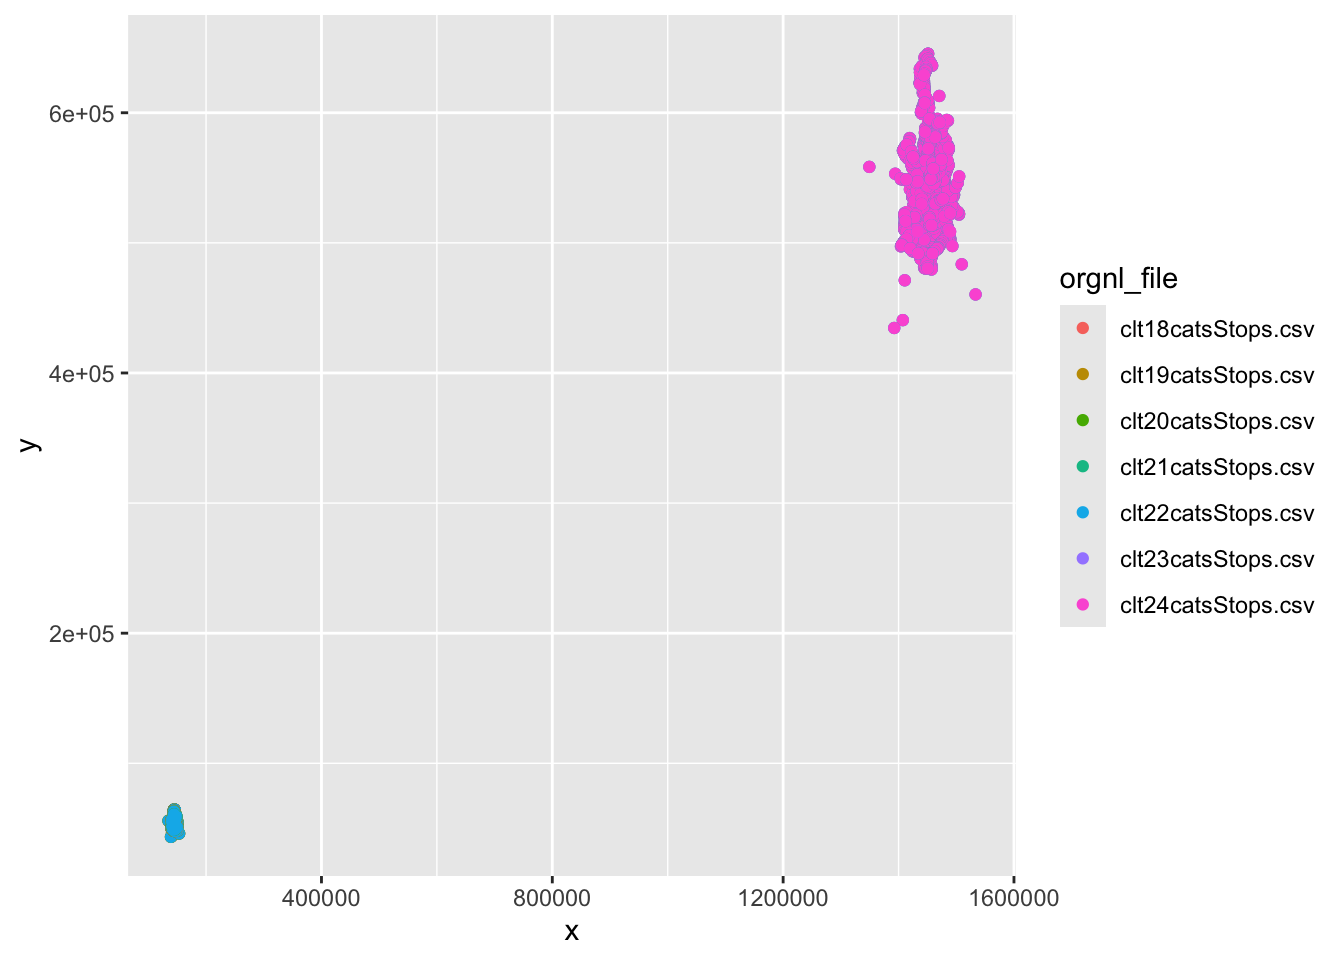

In [ ]:
busstop_data |>
  arrange(StopID) |>
  ggplot() +
  geom_point(aes(x = x, y = y, color = orgnl_file))


I noticed that some files have an extra digit at the end, so I selected all the files with common lat lon formats and made two plots.

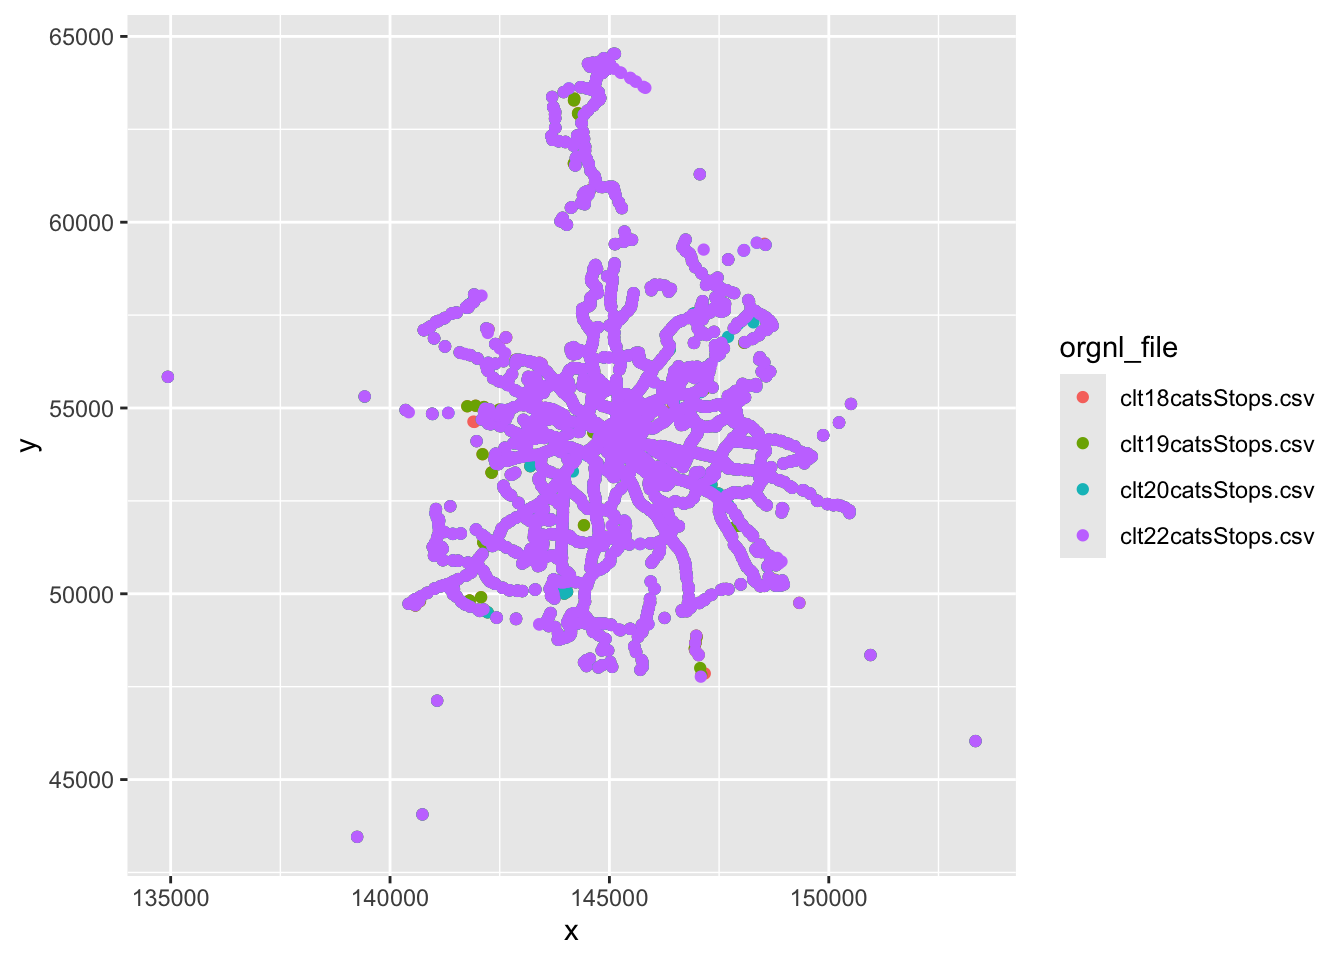

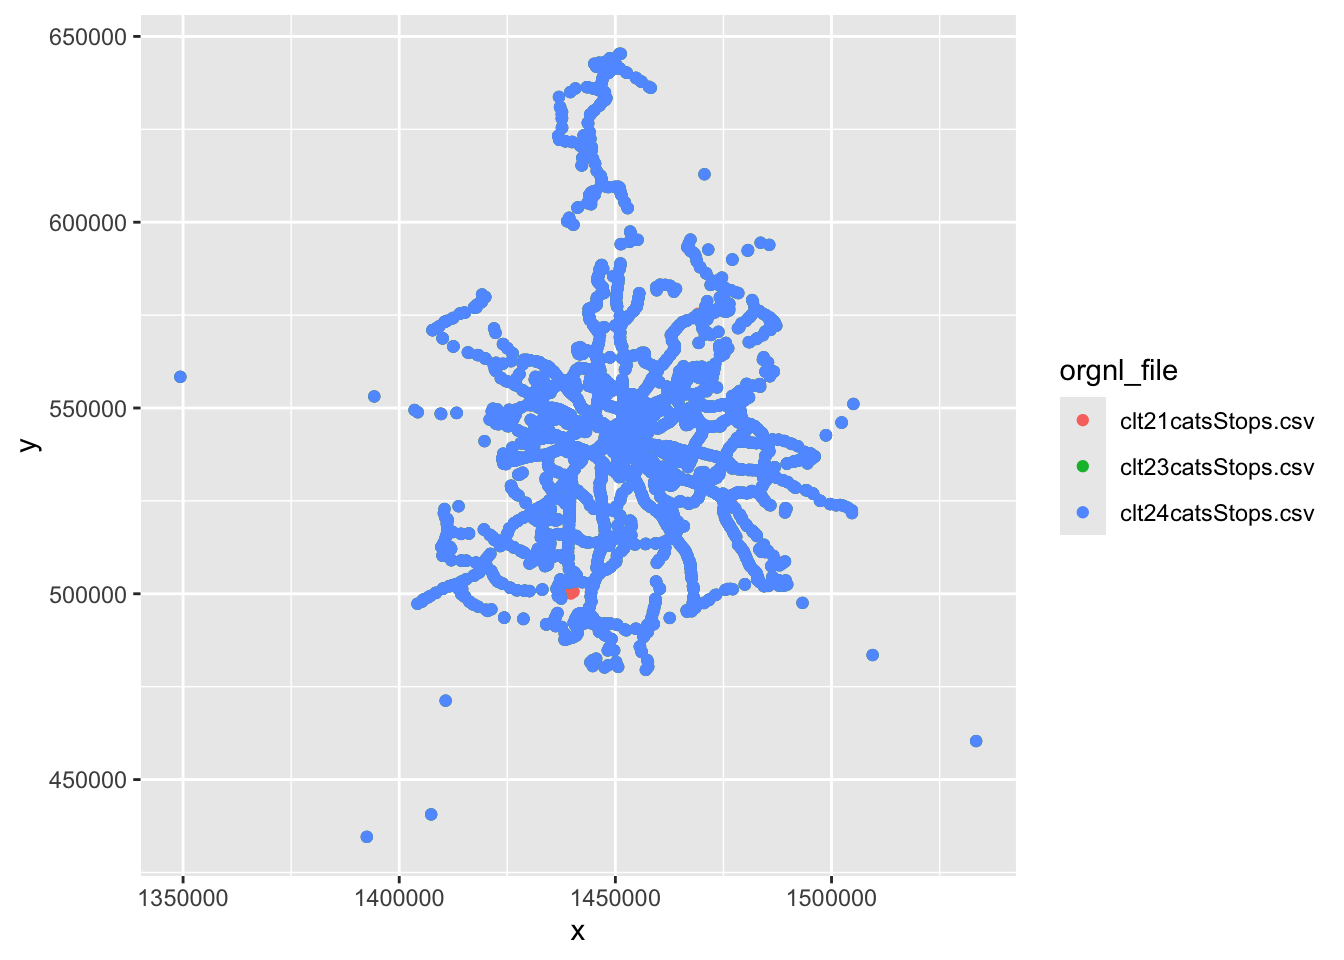

In [ ]:
busstop_data |>
  filter(orgnl_file %in% c("clt18catsStops.csv",
                           "clt19catsStops.csv",
                           "clt20catsStops.csv",
                           "clt22catsStops.csv")) |>
  ggplot() +
  geom_point(aes(x = x, y = y, color = orgnl_file))


testing to see if I can get all stops on the same map

small: These datasets have 5 or 6 digits in the coordinates

In [ ]:
small_coords_stops <- busstop_data |>
  filter(orgnl_file %in% c("clt18catsStops.csv",
                           "clt19catsStops.csv",
                           "clt20catsStops.csv",
                           "clt22catsStops.csv")) |>
  mutate(x = x*10, y = y*10)


big: These datasets have 6 or 7 digits in the coordinates

In [ ]:
big_coords_stops <- busstop_data |>
  filter(orgnl_file %in% c("clt23catsStops.csv",
                           "clt24catsStops.csv",
                           "clt21catsStops.csv"))


this df has combined the data after adjusting the coordinates

In [ ]:
bound_stops <- bind_rows(small_coords_stops, big_coords_stops) |>
  mutate(lon = x / 10000,
         lat = y / 10000)


Now I just need to find out how to get the coordinates as an sf object to plot on the map correctly. I am not done with this code chunk yet. I think I am doing something wrong with the crs.

Loading required namespace: raster

Zoom: 7

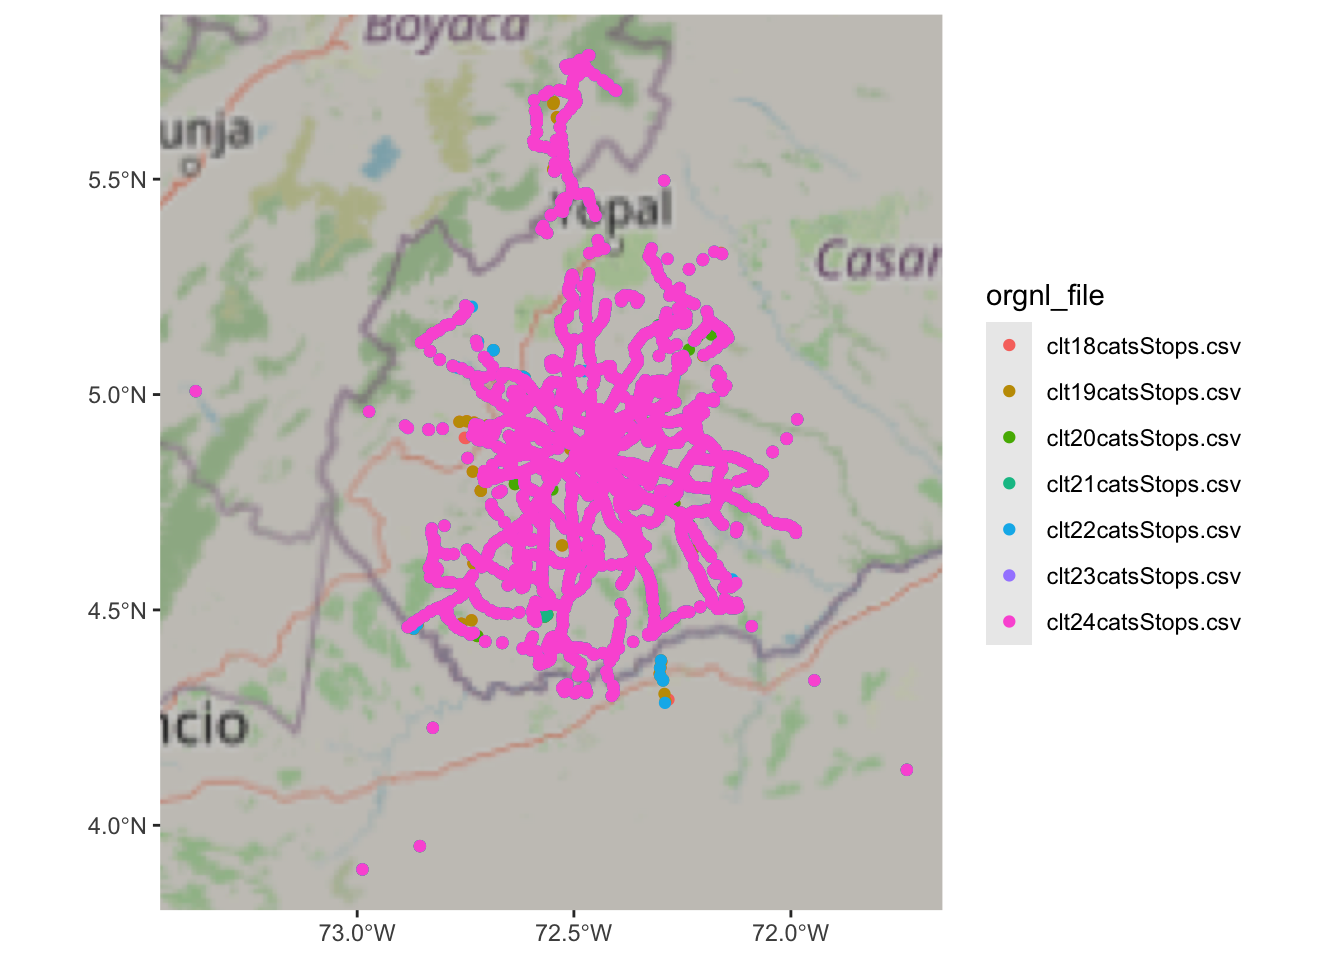

In [ ]:
df_sf <- st_as_sf(bound_stops, coords = c("lat", "lon"), crs = 4326)

# 1. Turn coordinates into sf object (assuming CRS 32610 - UTM Zone 10N)
df_sf <- st_as_sf(bound_stops, coords = c("x", "y"), crs = 26917)
# 2. Transform to Lat/Long (WGS84, EPSG:4326)
df_longlat <- st_transform(df_sf, crs = 4326)

ggplot(df_sf) +
  annotation_map_tile() +
  geom_sf(aes(color = orgnl_file))
